# Task 1: Apply Principal Component Analysis (PCA) for feature extraction and dimensionality reduction

Subtask 1.1: Data Acquisition and Feature Standardization

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
from sklearn.datasets import load_iris

In [4]:
from sklearn.preprocessing import StandardScaler

In [7]:
raw_iris=load_iris()

In [8]:
features = raw_iris.feature_names
X_raw = raw_iris.data
y_true = raw_iris.target

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [10]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)
iris_df['species_id'] = y_true

In [11]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}
iris_df['species_name'] = iris_df['species_id'].map(species_map)

In [12]:
print("Standardized dataset dimensions:", X_scaled.shape)

Standardized dataset dimensions: (150, 4)


In [13]:
print("\nFirst 3 rows of standardized dataset:")
print(iris_df.head(3))


First 3 rows of standardized dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


Subtask 1.2: Covariance Matrix and Eigenvalue Decomposition

In [14]:
cov_matrix = np.cov(X_scaled.T)
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [15]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues (Variance components):\n", eigenvalues)
print("\nEigenvectors (Principal Axes):\n", eigenvectors)



Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


Subtask 1.3: Implementing Dimensionality Reduction via PCA

In [16]:
from sklearn.decomposition import PCA

In [17]:
pca_model = PCA(n_components=2, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)


In [18]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])
pca_df['species_name'] = iris_df['species_name']


In [19]:
print("Transformed PCA space dimensions:", X_pca.shape)
print("\nFirst 3 projected coordinates:")
print(pca_df.head(3))

Transformed PCA space dimensions: (150, 2)

First 3 projected coordinates:
       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


Subtask 1.4: Visualizing the 2D PCA Feature Space

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

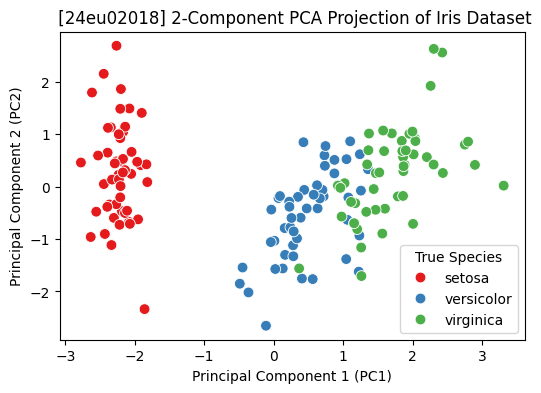

In [21]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title(" [24eu02018] 2-Component PCA Projection of Iris Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()

Subtask 1.5: Analyzing Explained Variance Ratio

In [22]:
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.sum(explained_variance)


In [23]:
print("Explained Variance per Component:")
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

Explained Variance per Component:
  PC1: 72.96%
  PC2: 22.85%


In [24]:
print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


Total Cumulative Variance Retained by 2 Components: 95.81%


# Task 2: Design clustering models using K-Means clustering for pattern discovery and data grouping

Subtask 2.1: Determining Clusters via the Elbow Method (WCSS)

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [26]:
wcss = []
k_range = range(1, 11)

In [27]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


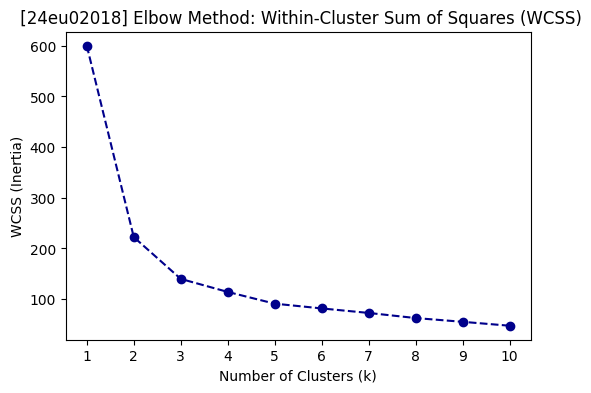

In [28]:
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title(" [24eu02018] Elbow Method: Within-Cluster Sum of Squares (WCSS)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()

Subtask 2.2: Validating Optimal Clusters with Silhouette Analysis

In [29]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_eval = range(2, 6)


In [30]:
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

/tmp/ipykernel_1008/2462795754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')


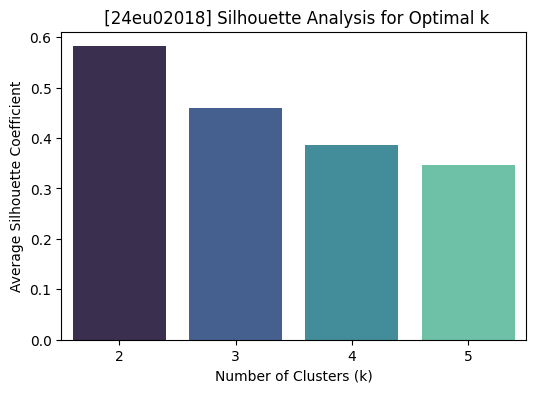

In [31]:
plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title(" [24eu02018] Silhouette Analysis for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()


In [32]:
best_k = k_eval[np.argmax(silhouette_scores)]
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")

k = 2 yielded the highest silhouette coefficient (0.5818).


Subtask 2.3: Implementing K-Means Clustering on the Raw Feature Space

In [33]:
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)

In [34]:
iris_df['cluster_raw'] = kmeans_raw_labels
print("K-Means clustering complete. First 5 sample allocations:")
print(iris_df[['species_name', 'cluster_raw']].head(5))

K-Means clustering complete. First 5 sample allocations:
  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


Subtask 2.4: Extracting and Inspecting Cluster Centroids

In [35]:
# Extract raw centroid coordinates in standardized space
raw_centroids_scaled = kmeans_raw.cluster_centers_

# Inverse transform centroids back to original physical measurements (cm)
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

In [36]:
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)
centroids_df.index = [f"Cluster_{i}" for i in range(3)]

print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")
print(centroids_df)

--- Estimated Cluster Centroids (Original Physical Units - cm) ---
           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster_0           5.801887          2.673585           4.369811   
Cluster_1           5.006000          3.428000           1.462000   
Cluster_2           6.780851          3.095745           5.510638   

           petal width (cm)  
Cluster_0          1.413208  
Cluster_1          0.246000  
Cluster_2          1.972340  


Subtask 2.5: Visualizing Raw Clusters and Centroids

In [37]:
plt.figure(figsize=(6, 4))

# Convert standardized centroids to original units for plotting
raw_data = scaler.inverse_transform(X_scaled)

<Figure size 600x400 with 0 Axes>

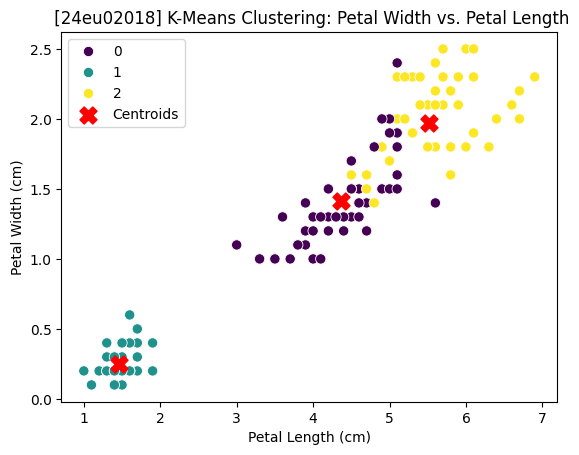

In [38]:
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')

# Plot the calculated centroids on the same canvas
plt.scatter(
    raw_centroids_physical[:, 2],
    raw_centroids_physical[:, 3],
    color='red',
    marker='X',
    s=150,
    label='Centroids'
)

plt.title(" [24eu02018] K-Means Clustering: Petal Width vs. Petal Length")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()

# Task 3: Analyze clustering performance and compare transformed feature spaces for improved data interpretation

Subtask 3.1: K-Means Clustering in the PCA-Reduced Space

In [39]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans

In [40]:
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

# Append to main DataFrame
iris_df['cluster_pca'] = kmeans_pca_labels
print("PCA space K-Means clustering completed successfully.")

PCA space K-Means clustering completed successfully.


Subtask 3.2: Internal Validation Metrics (Silhouette and Calinski-Harabasz Scores)

In [41]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [42]:
sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)


In [43]:
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)

In [44]:
print("--- Internal Validation (Unsupervised Quality Metrics) ---")
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")

--- Internal Validation (Unsupervised Quality Metrics) ---
Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90
PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


Subtask 3.3: Faceted Visual Comparison: K-Means Clusters vs. True Species

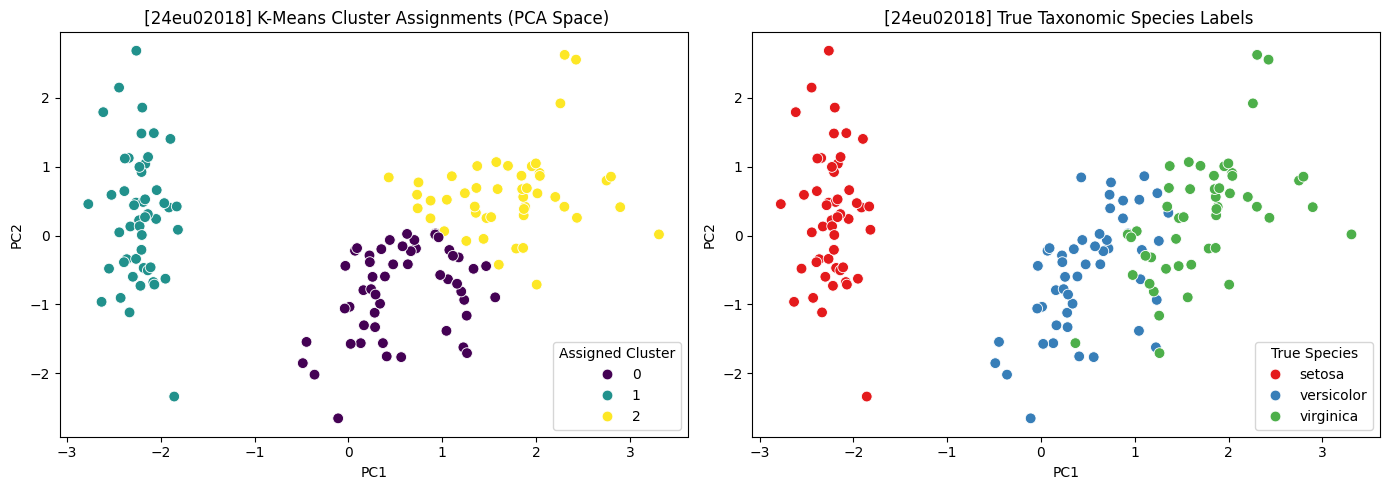

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels,
    palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title(" [24eu02018] K-Means Cluster Assignments (PCA Space)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Assigned Cluster')

# Plot 2: PCA Coordinates colored by true species labels
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name',
    palette='Set1', s=60, ax=axes[1]
)
axes[1].set_title(" [24eu02018] True Taxonomic Species Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='True Species')

plt.tight_layout()
plt.show()